In [17]:
#读取数据以及定义常量
import numpy as np
import pandas as pd
import utils
from gauss import GPR
import matplotlib.pyplot as plt
np.random.seed(42)
KERNEL_NU = 1.5
plt.rcParams.update({
    'font.size': 20,
    'font.family': 'serif', 
    'mathtext.fontset': 'stix',
    'axes.linewidth': 1.2,
    'xtick.major.size': 5, 
    'xtick.major.width': 1.2,
    'ytick.major.size': 5,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.fontsize': 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})
MB_list = [-19.253, -19.384]
MB_err_list = [0.027, 0.052]
MB_name_list = ['R22', 'DB23']
#bao数据
z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)

mask_dm, mask_dh = (bao_type == 'DM_over_rs'), (bao_type == 'DH_over_rs')
dm_rs, dh_rs = bao_val[mask_dm], bao_val[mask_dh]
z_exclude_dv = z_bao[mask_dh]
idx_use = np.where(mask_dh)[0]

To reconstruct the angular diameter distance $D_A(z)$ independent of the sound horizon $r_s$, we combine the transverse ($D_M/r_s$) and radial ($D_H/r_s$) BAO measurements with the reconstructed Hubble rate $H(z)$:
$$
D_A(z) = \frac{c}{(1+z)H(z)} \frac{D_M(z)/r_s}{D_H(z)/r_s}.
$$
The covariance matrix for $D_A$, denoted as $\mathbf{C}_{D_A}$, is obtained via the Jacobian error propagation method assuming independence between BAO measurements and the reconstructed $H(z)$:
$$
\mathbf{C}_{D_A} = \mathbf{J}_{BAO} \mathbf{C}_{BAO} \mathbf{J}_{BAO}^T + \mathbf{J}_{H} \mathbf{C}_{H} \mathbf{J}_{H}^T,
$$
where $\mathbf{C}_{BAO}$ and $\mathbf{C}_{H}$ are the covariance matrices for the BAO data and the reconstructed Hubble parameter, respectively. The Jacobian matrices are defined diagonally as:
$$
\mathbf{J}_{BAO} = \left[ \text{diag}\left(\frac{D_A}{D_M/r_s}\right), \; \text{diag}\left(-\frac{D_A}{D_H/r_s}\right) \right], \quad \mathbf{J}_{H} = \text{diag}\left(-\frac{D_A}{H(z)}\right).
$$
Finally, assuming the validity of the Etherington reciprocity theorem ($\eta=1$), we convert to luminosity distance $D_L(z) = (1+z)^2 D_A(z)$ and propagate the errors:
$$
\mathbf{C}_{D_L} = \mathbf{S} \mathbf{C}_{D_A} \mathbf{S}^T, \quad \text{with} \quad \mathbf{S} = \text{diag}\left((1+z)^2\right).
$$

In [18]:
h_match, h_cov = np.load("output/cc_baomatch_mean_GPR.npy"), np.load("output/cc_baomatch_cov_GPR.npy")
hz_exclude_dv, hz_exclude_dv_cov = h_match[idx_use], h_cov[np.ix_(idx_use, idx_use)]

In [19]:
c = 299792.458
da = dm_rs / dh_rs * c / (1 + z_exclude_dv) / hz_exclude_dv

idx = np.concatenate([np.where(mask_dm)[0], np.where(mask_dh)[0]])
j_bao = np.hstack([np.diag(da/dm_rs), np.diag(-da/dh_rs)])
j_hz = np.diag(-da/hz_exclude_dv)
da_cov = j_bao @ bao_cov[np.ix_(idx, idx)] @ j_bao.T + j_hz @ hz_exclude_dv_cov @ j_hz.T

scale = (1 + z_exclude_dv)**2
dl = da * scale
dl_cov = da_cov * np.outer(scale, scale)

print(f"DA: {da}\nDA_err: {np.sqrt(np.diag(da_cov))}")
print(f"DL: {dl}\nDL_err: {np.sqrt(np.diag(dl_cov))}")

DA: [1384.58788345 1545.28057715 1573.05411287 1677.68161147 1818.56925221
 2164.72836056]
DA_err: [103.39525232 108.03977375 103.40400717 112.39137356 149.75358609
 478.51277433]
DL: [ 3156.99883306  4497.44022184  5883.78238939  9037.73962594
 11221.03783988 24004.4563174 ]
DL_err: [ 235.7515148   314.44284695  386.76779864  605.45693742  924.0179631
 5306.18030327]


In [20]:
# 对mB作高斯过程回归
from gauss import GPR
sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn, mB_obs, err_sn = sn_df['zHD'].values, sn_df['m_b_corr'].values, sn_df['m_b_corr_err_DIAG'].values
mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")

# mask = (sn_df['IS_CALIBRATOR'] == 0) # 去掉了有chephid的样本
# z_sn = sn_df.loc[mask, 'zHD'].values
# mB_obs = sn_df.loc[mask, 'm_b_corr'].values

# idx_sn = sn_df.index[mask].values
# mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")
# mB_cov = mB_cov[np.ix_(idx_sn, idx_sn)]


# gpr = GPR(l=1.0, sigma_f=100, kernel_name='rbf') 
# gpr.fit(np.log(z_sn), mB_obs, mB_cov, optimize_method='minimize') 

# mB_baomatch_mean, mB_baomatch_cov = gpr.predict(np.log(z_bao))
# mB_baomatch_std = np.sqrt(np.diag(mB_baomatch_cov))
# np.save('output/mB_baomatch_mean_GPR_minimize.npy', mB_baomatch_mean)
# np.save('output/mB_baomatch_cov_GPR_minimize.npy', mB_baomatch_cov)
# print(f"Optimized hyperparameters: l={gpr.l:.3f}, sigma_f={gpr.sigma_f:.3f}")
mB_baomatch_mean, mB_baomatch_cov = np.load('output/mB_baomatch_mean_GPR.npy'), np.load('output/mB_baomatch_cov_GPR.npy')
mB_baomatch_mean, mB_baomatch_cov = mB_baomatch_mean[idx_use], mB_baomatch_cov[np.ix_(idx_use, idx_use)]

In [21]:
z_sn.shape

(1701,)

In [22]:
mB_baomatch_mean.shape

(6,)

Best MB: -19.4242 +/- 0.1061
Min Chi2: 3.14


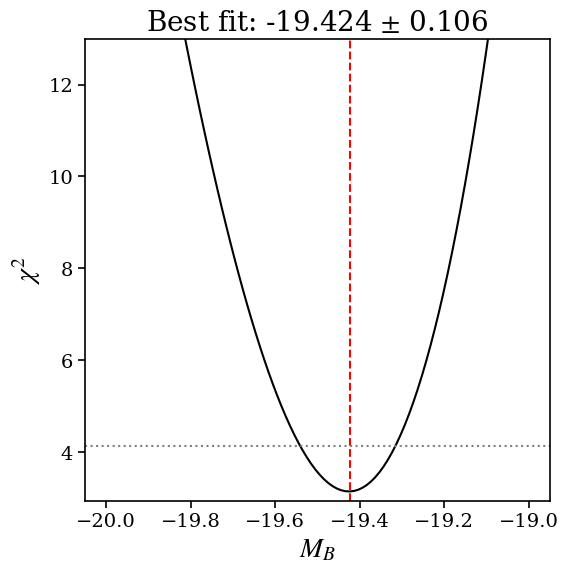

In [23]:
n_MC = 1000
MB_grid = np.linspace(-20, -19, 100)
chi2_list = []

mB_baomatch_samples = np.random.multivariate_normal(mB_baomatch_mean, mB_baomatch_cov, size=n_MC)

DL_bao_samples = np.random.multivariate_normal(dl, dl_cov, size=n_MC)


for MB_val in MB_grid:
    DL_sn_samples = 10**((mB_baomatch_samples - MB_val - 25) / 5)
    
    eta_samples = DL_sn_samples / DL_bao_samples
    eta_mean = np.mean(eta_samples, axis=0)
    eta_cov = np.cov(eta_samples, rowvar=False)
    
    diff = eta_mean - 1.0
    cinv = np.linalg.inv(eta_cov)
    chi2 = diff.T @ cinv @ diff
        
    chi2_list.append(chi2)

chi2_arr = np.array(chi2_list)
min_idx = np.argmin(chi2_arr)
best_MB = MB_grid[min_idx]
min_chi2 = chi2_arr[min_idx]

delta_chi2 = chi2_arr - min_chi2
sigma_region = MB_grid[delta_chi2 <= 1.0]
mb_err_low = best_MB - sigma_region[0]
mb_err_high = sigma_region[-1] - best_MB
best_mb_err = (mb_err_low + mb_err_high) / 2 # 取平均

print(f"Best MB: {best_MB:.4f} +/- {best_mb_err:.4f}")
print(f"Min Chi2: {min_chi2:.2f}")

plt.figure(figsize=(6, 6))
plt.plot(MB_grid, chi2_arr, 'black', label=r'$\chi^2$ Profile')
plt.axvline(best_MB, color='r', linestyle='--', label=f'Best $M_B$={best_MB:.3f}')
plt.axhline(min_chi2 + 1, color='grey', linestyle=':', label=r'$1\sigma$ region')
plt.xlabel(r'$M_B$')
plt.ylabel(r'$\chi^2$')
plt.ylim(min(chi2_arr)-0.2,13)
# plt.legend()
plt.title(f'Best fit: {best_MB:.3f} $\pm$ {best_mb_err:.3f}')
# plt.tight_layout()
plt.savefig('fig/bestfit_GPR.pdf', bbox_inches='tight')
plt.show()


In [24]:
best_DL_sn_samples = 10**((mB_baomatch_samples - best_MB - 25) / 5)
best_eta_samples = best_DL_sn_samples / DL_bao_samples
best_eta_mean = np.mean(best_eta_samples, axis=0)
best_eta_cov = np.cov(best_eta_samples, rowvar=False)
best_DL_sn_mean = np.mean(best_DL_sn_samples, axis=0)
best_DL_sn_cov = np.cov(best_DL_sn_samples, rowvar=False)

In [25]:
#LCDM predict
z_plot = np.linspace(0.05, 2.5, 500)
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=67.4, Om0=0.315)
DL = cosmo.luminosity_distance(z_plot).value 

R22 (MB=-19.253): chi2=5.52, p=0.4786, sigma=0.71
DB23 (MB=-19.384): chi2=3.25, p=0.7769, sigma=0.28
Best fit: chi2=3.14, p=0.7910, sigma=0.26


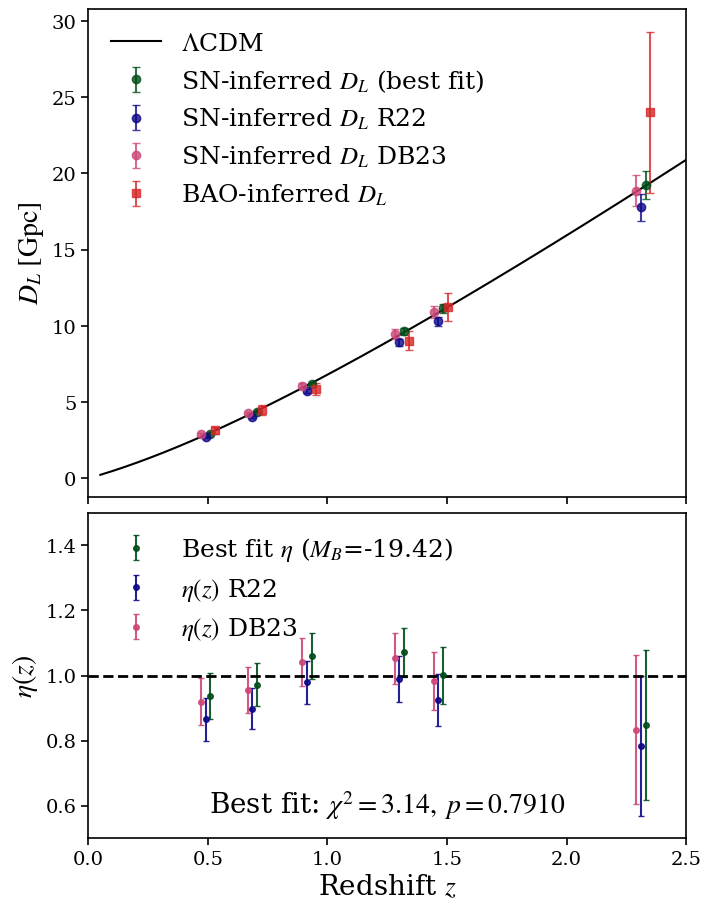

In [26]:
from scipy.stats import norm

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7, 9),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={'height_ratios': [3, 2]}
)

ax1.plot(z_plot, DL/1000, color='black', label=r'$\Lambda$CDM')

ax1.errorbar(
    z_exclude_dv, best_DL_sn_mean/1000, np.sqrt(np.diag(best_DL_sn_cov))/1000,
    fmt='o', label=rf'SN-inferred $D_L$ (best fit)', capsize=3, color="#004d1a", alpha=0.8
)

for i, (MB_val, MB_err, MB_name) in enumerate(zip(MB_list, MB_err_list, MB_name_list)):
    MB_samples = np.random.normal(MB_val, MB_err, n_MC)
    DL_sn_samples = 10**((mB_baomatch_samples - MB_samples[:, np.newaxis] - 25) / 5)
    DL_sn_mean = np.mean(DL_sn_samples, axis=0)
    DL_sn_cov = np.cov(DL_sn_samples, rowvar=False)
    ax1.errorbar(
        z_exclude_dv-(i+1)*0.02, DL_sn_mean/1000, np.sqrt(np.diag(DL_sn_cov))/1000,
        fmt='o', label=rf'SN-inferred $D_L$ {MB_name}', capsize=3, alpha=0.8, color=plt.cm.plasma(i / len(MB_list))
    )

ax1.errorbar(
    z_exclude_dv+0.02, dl/1000, np.sqrt(np.diag(dl_cov))/1000,
    fmt='s', label=r'BAO-inferred $D_L$', capsize=3, color='#d62728', alpha=0.8
)

ax1.set_ylabel(r'$D_L\ \mathrm{[Gpc]}$')
ax1.legend(fontsize=18)

ax2.errorbar(
    z_exclude_dv, best_eta_mean, np.sqrt(np.diag(best_eta_cov)),
    fmt='o', ms=4, capsize=2, label=f'Best fit $\eta$ ($M_B$={best_MB:.2f})', alpha=0.9, color="#004d1a"
)

for i, (MB_val, MB_err, MB_name) in enumerate(zip(MB_list, MB_err_list, MB_name_list)):
    MB_samples = np.random.normal(MB_val, MB_err, n_MC)
    DL_sn_samples = 10**((mB_baomatch_samples - MB_samples[:, np.newaxis] - 25) / 5)
    eta_samples = DL_sn_samples / DL_bao_samples
    eta_mean = np.mean(eta_samples, axis=0)
    eta_cov = np.cov(eta_samples, rowvar=False)
    chi2_val, p_val = utils.eta_chi2(eta_mean, eta_cov)
    
    sigma_val = norm.isf(p_val / 2)
    print(f"{MB_name} (MB={MB_val}): chi2={chi2_val:.2f}, p={p_val:.4f}, sigma={sigma_val:.2f}")
    
    ax2.errorbar(
        z_exclude_dv-(i+1)*0.02, eta_mean, np.sqrt(np.diag(eta_cov)),
        fmt='o', ms=4, capsize=2, label=rf'$\eta(z)$ {MB_name}', alpha=0.9, color=plt.cm.plasma(i / len(MB_list))
    )

ax2.axhline(
    1.0, color='black', linestyle='--', linewidth=2
)

ax2.set_ylim(0.5, 1.5)
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'$\eta(z)$')
ax2.legend(loc='upper left', fontsize=18)
chi2_val, p_val = utils.eta_chi2(best_eta_mean, best_eta_cov)

best_sigma_val = norm.isf(p_val / 2)
print(f"Best fit: chi2={chi2_val:.2f}, p={p_val:.4f}, sigma={best_sigma_val:.2f}")

plt.text(0.5, 0.05,
         rf'Best fit: $\chi^2 = {chi2_val:.2f},\ p = {p_val:.4f}$',
         ha='center', va='bottom',
         transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round,pad=0.3',
                   facecolor='white', alpha=1, edgecolor='none'))
plt.xlim(0, 2.5)
plt.savefig('fig/measurement_GPR.pdf', bbox_inches='tight')
plt.show()

FKM Method

In [27]:
mB_baomatch_mean, mB_baomatch_cov = np.load('output/mB_baomatch_mean_FKM.npy'), np.load('output/mB_baomatch_cov_FKM.npy')
mB_baomatch_mean, mB_baomatch_cov= mB_baomatch_mean[idx_use], mB_baomatch_cov[np.ix_(idx_use, idx_use)]
h_match, h_cov = np.load("output/cc_baomatch_mean_FKM.npy"), np.load("output/cc_baomatch_cov_FKM.npy")
hz_exclude_dv, hz_exclude_dv_cov = h_match[idx_use], h_cov[np.ix_(idx_use, idx_use)]

In [28]:
c = 299792.458
da = dm_rs / dh_rs * c / (1 + z_exclude_dv) / hz_exclude_dv

idx = np.concatenate([np.where(mask_dm)[0], np.where(mask_dh)[0]])
j_bao = np.hstack([np.diag(da/dm_rs), np.diag(-da/dh_rs)])
j_hz = np.diag(-da/hz_exclude_dv)
da_cov = j_bao @ bao_cov[np.ix_(idx, idx)] @ j_bao.T + j_hz @ hz_exclude_dv_cov @ j_hz.T

scale = (1 + z_exclude_dv)**2
dl = da * scale
dl_cov = da_cov * np.outer(scale, scale)

print(f"DA: {da}\nDA_err: {np.sqrt(np.diag(da_cov))}")
print(f"DL: {dl}\nDL_err: {np.sqrt(np.diag(dl_cov))}")

DA: [1434.9380514  1637.72358307 1488.19918526 1657.38455278 1761.72466
 1839.50245517]
DA_err: [113.283293   138.28354077 132.8660604  116.8504609  141.52099058
 401.692218  ]
DL: [ 3271.80225099  4766.48967422  5566.39475179  8928.39853862
 10870.29215371 20398.05877514]
DL_err: [ 258.29723638  402.46539525  496.96636623  629.47822371  873.22074124
 4454.32483617]


In [29]:
mB_baomatch_samples = np.random.multivariate_normal(mB_baomatch_mean, mB_baomatch_cov, size=n_MC)

DL_bao_samples = np.random.multivariate_normal(dl, dl_cov, size=n_MC)

Best MB: -19.4444 +/- 0.1061
Min Chi2: 8.57


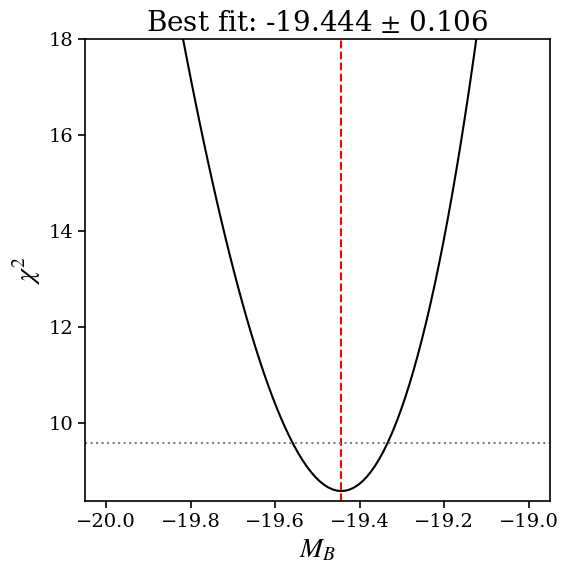

In [30]:
n_MC = 1000
MB_grid = np.linspace(-20, -19, 100)
chi2_list = []

for MB_val in MB_grid:
    DL_sn_samples = 10**((mB_baomatch_samples - MB_val - 25) / 5)
    
    eta_samples = DL_sn_samples / DL_bao_samples
    eta_mean = np.mean(eta_samples, axis=0)
    eta_cov = np.cov(eta_samples, rowvar=False)
    
    diff = eta_mean - 1.0
    cinv = np.linalg.inv(eta_cov)
    chi2 = diff.T @ cinv @ diff
        
    chi2_list.append(chi2)

chi2_arr = np.array(chi2_list)
min_idx = np.argmin(chi2_arr)
best_MB = MB_grid[min_idx]
min_chi2 = chi2_arr[min_idx]

delta_chi2 = chi2_arr - min_chi2
sigma_region = MB_grid[delta_chi2 <= 1.0]
mb_err_low = best_MB - sigma_region[0]
mb_err_high = sigma_region[-1] - best_MB
best_mb_err = (mb_err_low + mb_err_high) / 2 # 取平均

print(f"Best MB: {best_MB:.4f} +/- {best_mb_err:.4f}")
print(f"Min Chi2: {min_chi2:.2f}")

plt.figure(figsize=(6, 6))
plt.plot(MB_grid, chi2_arr, 'black', label=r'$\chi^2$ Profile')
plt.axvline(best_MB, color='r', linestyle='--', label=f'Best $M_B$={best_MB:.3f}')
plt.axhline(min_chi2 + 1, color='grey', linestyle=':', label=r'$1\sigma$ region')
plt.xlabel(r'$M_B$')
plt.ylabel(r'$\chi^2$')
plt.ylim(min(chi2_arr)-0.2,18)
# plt.legend()
plt.title(f'Best fit: {best_MB:.3f} $\pm$ {best_mb_err:.3f}')
# plt.tight_layout()
plt.savefig('fig/bestfit_FKM.pdf', bbox_inches='tight')
plt.show()


In [31]:
best_DL_sn_samples = 10**((mB_baomatch_samples - best_MB - 25) / 5)
best_eta_samples = best_DL_sn_samples / DL_bao_samples
best_eta_mean = np.mean(best_eta_samples, axis=0)
best_eta_cov = np.cov(best_eta_samples, rowvar=False)
best_DL_sn_mean = np.mean(best_DL_sn_samples, axis=0)
best_DL_sn_cov = np.cov(best_DL_sn_samples, rowvar=False)

R22 (MB=-19.253): chi2=11.58, p=0.0721, sigma=1.80
DB23 (MB=-19.384): chi2=8.85, p=0.1820, sigma=1.33
Best fit: chi2=8.57, p=0.1989, sigma=1.28


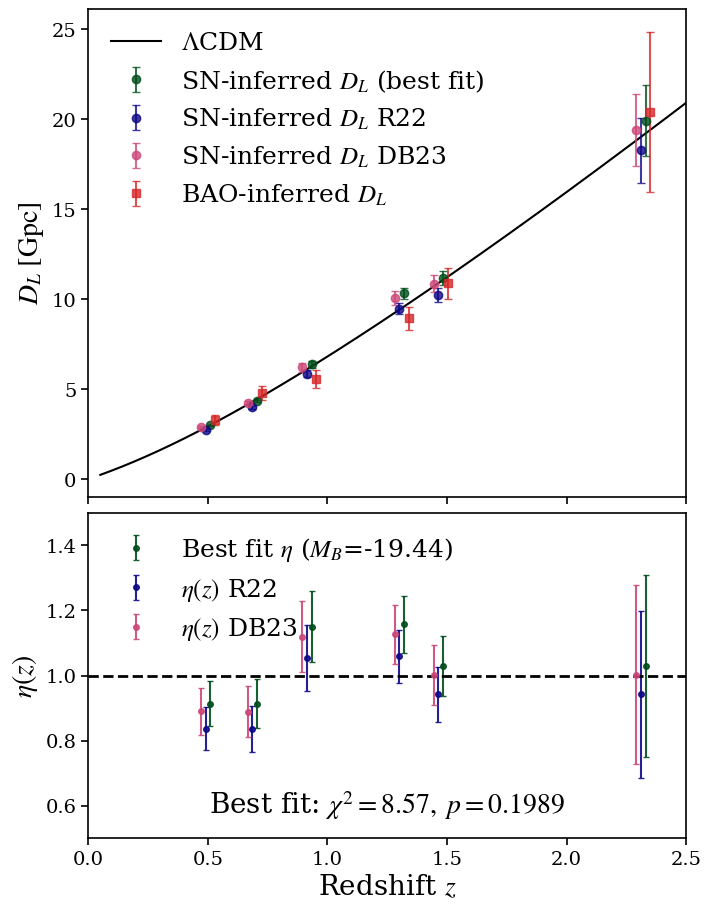

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7, 9),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={'height_ratios': [3, 2]}
)

ax1.plot(z_plot, DL/1000, color='black', label=r'$\Lambda$CDM')

ax1.errorbar(
    z_exclude_dv, best_DL_sn_mean/1000, np.sqrt(np.diag(best_DL_sn_cov))/1000,
    fmt='o', label=rf'SN-inferred $D_L$ (best fit)', capsize=3, color="#004d1a", alpha=0.8
)

for i, (MB_val, MB_err, MB_name) in enumerate(zip(MB_list, MB_err_list, MB_name_list)):
    MB_samples = np.random.normal(MB_val, MB_err, n_MC)
    DL_sn_samples = 10**((mB_baomatch_samples - MB_samples[:, np.newaxis] - 25) / 5)
    DL_sn_mean = np.mean(DL_sn_samples, axis=0)
    DL_sn_cov = np.cov(DL_sn_samples, rowvar=False)
    ax1.errorbar(
        z_exclude_dv-(i+1)*0.02, DL_sn_mean/1000, np.sqrt(np.diag(DL_sn_cov))/1000,
        fmt='o', label=rf'SN-inferred $D_L$ {MB_name}', capsize=3, alpha=0.8, color=plt.cm.plasma(i / len(MB_list))
    )

ax1.errorbar(
    z_exclude_dv+0.02, dl/1000, np.sqrt(np.diag(dl_cov))/1000,
    fmt='s', label=r'BAO-inferred $D_L$', capsize=3, color='#d62728', alpha=0.8
)

ax1.set_ylabel(r'$D_L\ \mathrm{[Gpc]}$')
ax1.legend(fontsize=18)

ax2.errorbar(
    z_exclude_dv, best_eta_mean, np.sqrt(np.diag(best_eta_cov)),
    fmt='o', ms=4, capsize=2, label=f'Best fit $\eta$ ($M_B$={best_MB:.2f})', alpha=0.9, color="#004d1a"
)

for i, (MB_val, MB_err, MB_name) in enumerate(zip(MB_list, MB_err_list, MB_name_list)):
    MB_samples = np.random.normal(MB_val, MB_err, n_MC)
    DL_sn_samples = 10**((mB_baomatch_samples - MB_samples[:, np.newaxis] - 25) / 5)
    eta_samples = DL_sn_samples / DL_bao_samples
    eta_mean = np.mean(eta_samples, axis=0)
    eta_cov = np.cov(eta_samples, rowvar=False)
    
    chi2_val, p_val = utils.eta_chi2(eta_mean, eta_cov)
    
    sigma_val = norm.isf(p_val / 2) 
    
    print(f"{MB_name} (MB={MB_val}): chi2={chi2_val:.2f}, p={p_val:.4f}, sigma={sigma_val:.2f}")
    
    ax2.errorbar(
        z_exclude_dv-(i+1)*0.02, eta_mean, np.sqrt(np.diag(eta_cov)),
        fmt='o', ms=4, capsize=2, label=rf'$\eta(z)$ {MB_name}', alpha=0.9, color=plt.cm.plasma(i / len(MB_list))
    )

ax2.axhline(
    1.0, color='black', linestyle='--', linewidth=2
)

ax2.set_ylim(0.5, 1.5)
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'$\eta(z)$')
ax2.legend(loc='upper left', fontsize=18)

chi2_val, p_val = utils.eta_chi2(best_eta_mean, best_eta_cov)

best_sigma_val = norm.isf(p_val / 2)
print(f"Best fit: chi2={chi2_val:.2f}, p={p_val:.4f}, sigma={best_sigma_val:.2f}")

plt.text(0.5, 0.05,
         rf'Best fit: $\chi^2 = {chi2_val:.2f},\ p = {p_val:.4f}$',
         ha='center', va='bottom',
         transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round,pad=0.3',
                   facecolor='white', alpha=1, edgecolor='none'))

plt.xlim(0, 2.5)
# plt.tight_layout()
plt.savefig('fig/measurement_FKM.pdf', bbox_inches='tight')
plt.show()